In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score


In [ ]:
# Load UCI HAR features
X_train = pd.read_csv("X_train.txt", delim_whitespace=True, header=None)

print("Original shape:", X_train.shape)
X_train.head()


/tmp/ipython-input-762633632.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv("X_train.txt", delim_whitespace=True, header=None)


Original shape: (935, 561)


,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [ ]:
# 1. Columns containing NaNs
nan_cols = X_train.columns[X_train.isna().any()]

# 2. Near-zero variance columns
std_per_feature = X_train.std(axis=0)
near_zero_var_cols = std_per_feature[std_per_feature < 1e-6].index

# Combine columns to drop
cols_to_drop = set(nan_cols).union(set(near_zero_var_cols))

print("Columns with NaNs:", len(nan_cols))
print("Near-zero variance columns:", len(near_zero_var_cols))
print("Total columns dropped:", len(cols_to_drop))

# Drop them
X_clean = X_train.drop(columns=cols_to_drop)

print("Cleaned shape:", X_clean.shape)


Columns with NaNs: 363
Near-zero variance columns: 0
Total columns dropped: 363
Cleaned shape: (935, 198)


In [ ]:
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X_clean)

print("NaNs after imputation:", np.isnan(X_imputed).sum())


NaNs after imputation: 0


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print("NaNs after scaling:", np.isnan(X_scaled).sum())


NaNs after scaling: 0


In [ ]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)


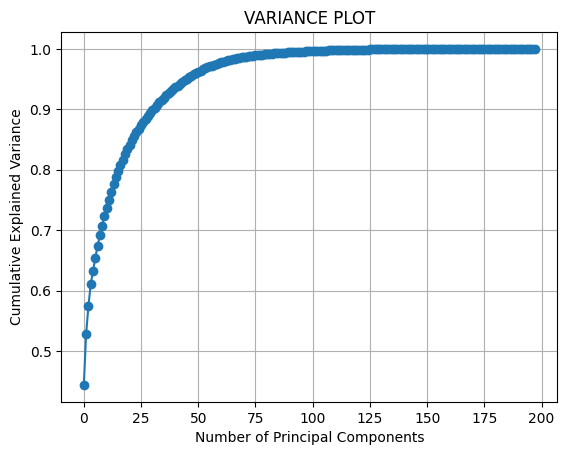

In [ ]:
explained_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure()
plt.plot(explained_var, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("VARIANCE PLOT")
plt.grid(True)
plt.show()


In [ ]:
pca_90 = PCA(n_components=0.90)
X_pca_90 = pca_90.fit_transform(X_scaled)

print("PCA (90%) shape:", X_pca_90.shape)


PCA (90%) shape: (935, 32)


In [ ]:
loadings = pd.DataFrame(
    pca_90.components_.T,
    columns=[f"PC{i+1}" for i in range(pca_90.n_components_)]
)

loadings.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32
0,0.001562,0.066693,0.078505,-0.070482,0.091310,-0.070132,0.091995,-0.056464,-0.082858,0.093326,...,0.141152,0.019871,0.223483,-0.008342,0.193876,0.089858,-0.143171,0.063735,-0.062730,0.124333
1,-0.006096,0.002833,0.046240,0.002646,0.034986,-0.003060,0.068280,0.020619,-0.041287,0.041037,...,0.022710,0.053718,-0.079900,0.106201,-0.056762,0.066584,0.413333,-0.234101,0.031785,-0.055084
2,-0.000865,-0.029020,-0.022657,0.029944,-0.024326,0.079341,-0.057960,-0.040727,0.074775,0.117746,...,-0.066613,0.381380,0.222077,0.027823,-0.096411,-0.147474,0.127999,-0.076058,0.141683,-0.007807
3,0.101422,0.017685,-0.039041,0.011788,0.021243,-0.075195,0.021613,-0.040337,0.011451,0.030268,...,-0.000367,0.002180,-0.004343,-0.061895,-0.000668,-0.021315,-0.008037,-0.022627,-0.003304,-0.058494
4,0.103590,-0.008041,-0.016053,0.014385,0.012191,-0.001478,-0.035869,0.026450,0.024052,0.036393,...,0.014722,-0.039843,-0.025849,-0.004469,0.016399,0.001465,0.016626,-0.019962,-0.003035,0.008075


Silhouette Score: 0.6928005788895888


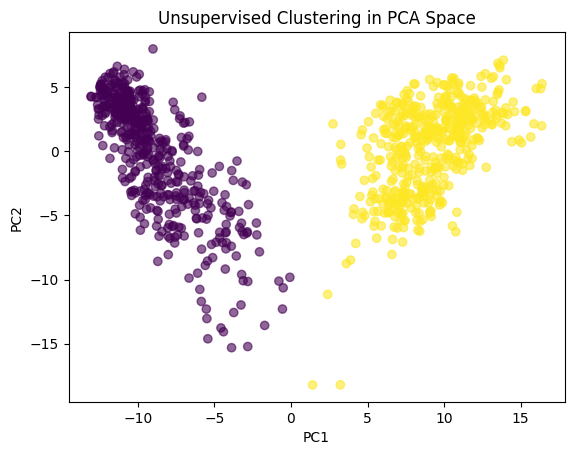

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# K-means clustering on first two PCs
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_pca_90[:, :2])

# Silhouette score
sil_score = silhouette_score(X_pca_90[:, :2], clusters)
print("Silhouette Score:", sil_score)

# Plot clusters in PCA space
plt.figure()
plt.scatter(
    X_pca_90[:, 0],
    X_pca_90[:, 1],
    c=clusters,
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Unsupervised Clustering in PCA Space")
plt.show()


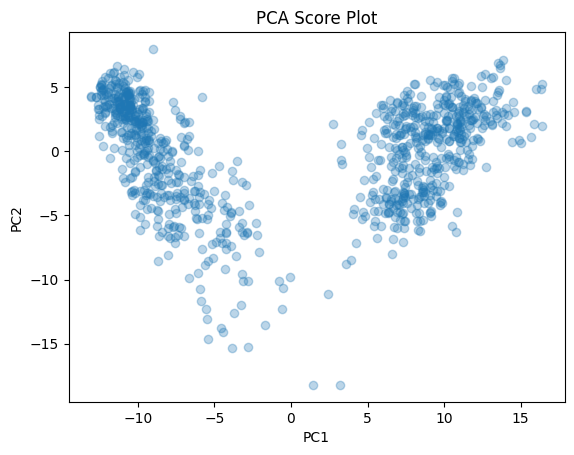

In [ ]:
plt.figure()
plt.scatter(X_pca_90[:, 0], X_pca_90[:, 1], alpha=0.3)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Score Plot")
plt.show()


In [ ]:
# Use PC2 distribution to define surrogate strategies
pc2 = pca_df['PC2']

low_control_thresh  = pc2.quantile(0.25)
high_control_thresh = pc2.quantile(0.75)

pca_df['strategy_group'] = 'normal'
pca_df.loc[pc2 < low_control_thresh, 'strategy_group'] = 'rigid_guarded'
pca_df.loc[pc2 > high_control_thresh, 'strategy_group'] = 'unstable_compensatory'

pca_df['strategy_group'].value_counts()


,count
strategy_group,
normal,467
unstable_compensatory,234
rigid_guarded,234


In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

normal = pca_df[pca_df['strategy_group'] == 'normal']
comp   = pca_df[pca_df['strategy_group'] != 'normal']

nbrs = NearestNeighbors(n_neighbors=1).fit(normal[['PC1']])
dist, idx = nbrs.kneighbors(comp[['PC1']])

matched_normal = normal.iloc[idx.flatten()].reset_index(drop=True)
matched_comp   = comp.reset_index(drop=True)

strategy_deficit = np.abs(matched_comp['PC2'].values - matched_normal['PC2'].values)

print("Mean Strategy Deficit:", strategy_deficit.mean())


Mean Strategy Deficit: 4.04413096476783


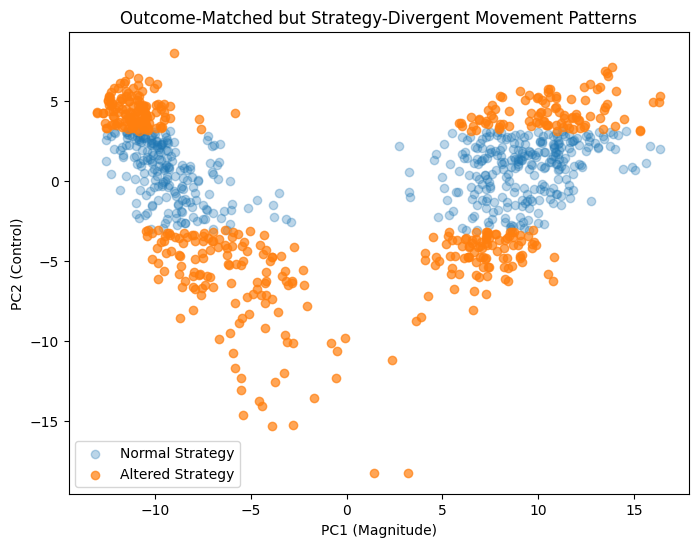

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    normal['PC1'], normal['PC2'],
    alpha=0.3, label='Normal Strategy'
)

plt.scatter(
    comp['PC1'], comp['PC2'],
    alpha=0.7, label='Altered Strategy'
)

plt.xlabel("PC1 (Magnitude)")
plt.ylabel("PC2 (Control)")
plt.title("Outcome-Matched but Strategy-Divergent Movement Patterns")
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_pca_90[:, :2], clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.6928005788895888


In [ ]:
import numpy as np
import pandas as pd

# Create DataFrame with PCA scores and cluster labels
cluster_df = pd.DataFrame({
    "PC1": X_pca_90[:, 0],
    "PC2": X_pca_90[:, 1],
    "Cluster": clusters
})

# Cluster sizes
cluster_sizes = cluster_df["Cluster"].value_counts().sort_index()
print("Cluster sizes:")
print(cluster_sizes)

# Cluster centroids (mean PC1, PC2 per cluster)
centroids = cluster_df.groupby("Cluster")[["PC1", "PC2"]].mean()
print("\nCluster centroids (PC1, PC2):")
print(centroids)


Cluster sizes:
Cluster
0    472
1    463
Name: count, dtype: int64

Cluster centroids (PC1, PC2):
              PC1       PC2
Cluster                    
0       -8.919473 -0.257094
1        9.092853  0.262092


In [ ]:
X_pca_90

array([[-12.54462135,   1.21110633,   0.22231417, ...,   0.5083585 ,
         -0.47554187,  -1.15784776],
       [ -9.88286967,   0.59020008,   2.9997134 , ...,   0.31452758,
          1.38826956,  -0.32663847],
       [ -9.74502788,   2.08408911,   4.40121801, ...,  -0.44264646,
          0.76746827,  -0.69006512],
       ...,
       [ 10.34388039,   1.81941039,   1.03789159, ...,  -0.26366194,
         -0.9513362 ,   0.68174747],
       [ 11.20190399,  -0.96521067,  -1.63709104, ...,   1.14920603,
          2.04859265,  -0.21631   ],
       [ 11.90039042,   0.89519166,  -0.85421208, ...,  -0.0800694 ,
         -0.95553206,  -0.36992336]])

In [74]:
## Reproducible Analysis
This notebook reproduces the PCA and clustering analysis presented in the paper:
"Beyond Performance Symmetry: Revealing Hidden Movement Strategies in RTS Assessment."


SyntaxError: invalid syntax (ipython-input-906398156.py, line 2)